# Scenario analysis

This quick analysis evaluates sector-specific deterministic scenarios around the current expected-input base case:

1. electricity: low / medium / high full-load-hour scenarios;
2. electricity: low / medium / high lifetime scenarios;
3. variable renewable electricity: minimum / base / maximum value-factor scenarios;
4. cement: low / medium / high CO2-price scenarios;
5. cement: low / medium / high discount-rate scenarios;
6. hydrogen: low / medium / high fuel-price, electricity-price, and investment-cost scenarios.
7. ammonia: low / medium / high electricity-price, investment-cost, and fuel-price scenarios.

The notebook uses deterministic base inputs from the reusable sensitivity helpers. It does not run Monte Carlo simulations for the scenario cases. Nothing is written to `src/`, `data/`, `results/`, or `figures/`.


In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ammonia.ammonia_npv_summary_figures import AMMONIA_TECHNOLOGY_LABELS
from cement.cement_npv_summary_figures import CEMENT_TECHNOLOGY_LABELS
from electricity.electricity_npv_summary_figures import ELECTRICITY_TECHNOLOGY_LABELS
from general_parameters import CARBON_PRICE_EUR_PER_T, INTEREST_RATE
from hydrogen.hydrogen_npv_summary_figures import HYDROGEN_TECHNOLOGY_LABELS
from sensitivity_analysis import (
    FINANCIAL_METRIC_OPTIONS,
    base_inputs,
    calculate_metric_value,
)


## Settings

The medium cases are the current deterministic assumptions. Electricity full-load-hour and lifetime scenarios and all hydrogen and ammonia scenarios use editable multipliers around each technology's own deterministic base value. Renewable value-factor and cement scenarios use explicit editable absolute values.


In [2]:
CURRENT_CO2_PRICE = CARBON_PRICE_EUR_PER_T.value
CURRENT_DISCOUNT_RATE = INTEREST_RATE.value

ELECTRICITY_FLH_MULTIPLIERS = {
    "Low": 0.80,
    "Medium": 1.00,
    "High": 1.20,
}
ELECTRICITY_LIFETIME_MULTIPLIERS = {
    "Low": 0.80,
    "Medium": 1.00,
    "High": 1.20,
}
ELECTRICITY_VALUE_FACTOR_SCENARIOS = {
    "wind_onshore": {"Min": 0.80, "Base": 0.90, "Max": 1.00},
    "wind_offshore": {"Min": 0.85, "Base": 0.95, "Max": 1.00},
    "pv": {"Min": 0.80, "Base": 0.90, "Max": 1.00},
}
CEMENT_CO2_PRICE_SCENARIOS = {
    "Low": 40.0,
    "Medium": CURRENT_CO2_PRICE,
    "High": 120.0,
}
CEMENT_DISCOUNT_RATE_SCENARIOS = {
    "Low": 0.04,
    "Medium": CURRENT_DISCOUNT_RATE,
    "High": 0.12,
}
HYDROGEN_INPUT_MULTIPLIERS = {
    "Low": 0.80,
    "Medium": 1.00,
    "High": 1.20,
}
AMMONIA_INPUT_MULTIPLIERS = {
    "Low": 0.80,
    "Medium": 1.00,
    "High": 1.20,
}

# Choose the financial metric used in the scenario figures and summary tables.
FINANCIAL_METRIC = "LNM"  # "NPV", "LNM", or "LCOX"

if FINANCIAL_METRIC not in FINANCIAL_METRIC_OPTIONS:
    raise ValueError(f"Unknown FINANCIAL_METRIC: {FINANCIAL_METRIC!r}")

pd.options.display.float_format = "{:,.3f}".format

scenario_settings = pd.DataFrame(
    [
        {
            "sector": "Electricity",
            "scenario_variable": "Full-load hours",
            "low": "80% of deterministic base",
            "medium": "deterministic base",
            "high": "120% of deterministic base",
        },
        {
            "sector": "Electricity",
            "scenario_variable": "Lifetime",
            "low": "80% of deterministic base",
            "medium": "deterministic base",
            "high": "120% of deterministic base",
        },
        {
            "sector": "Cement",
            "scenario_variable": "CO2 price",
            "low": CEMENT_CO2_PRICE_SCENARIOS["Low"],
            "medium": CEMENT_CO2_PRICE_SCENARIOS["Medium"],
            "high": CEMENT_CO2_PRICE_SCENARIOS["High"],
        },
        {
            "sector": "Cement",
            "scenario_variable": "Discount rate",
            "low": CEMENT_DISCOUNT_RATE_SCENARIOS["Low"],
            "medium": CEMENT_DISCOUNT_RATE_SCENARIOS["Medium"],
            "high": CEMENT_DISCOUNT_RATE_SCENARIOS["High"],
        },
        {
            "sector": "Hydrogen",
            "scenario_variable": "Fuel price",
            "low": "80% of technology-specific base",
            "medium": "technology-specific base",
            "high": "120% of technology-specific base",
        },
        {
            "sector": "Hydrogen",
            "scenario_variable": "Electricity price",
            "low": "80% of deterministic base",
            "medium": "deterministic base",
            "high": "120% of deterministic base",
        },
        {
            "sector": "Hydrogen",
            "scenario_variable": "Investment cost",
            "low": "80% of technology-specific base",
            "medium": "technology-specific base",
            "high": "120% of technology-specific base",
        },
        {
            "sector": "Ammonia",
            "scenario_variable": "Electricity price",
            "low": "80% of deterministic base",
            "medium": "deterministic base",
            "high": "120% of deterministic base",
        },
        {
            "sector": "Ammonia",
            "scenario_variable": "Investment cost",
            "low": "80% of technology-specific base",
            "medium": "technology-specific base",
            "high": "120% of technology-specific base",
        },
        {
            "sector": "Ammonia",
            "scenario_variable": "Fuel price",
            "low": "80% of technology-specific base",
            "medium": "technology-specific base",
            "high": "120% of technology-specific base",
        },
    ]
)
value_factor_settings = (
    pd.DataFrame.from_dict(ELECTRICITY_VALUE_FACTOR_SCENARIOS, orient="index")
    .rename(index=ELECTRICITY_TECHNOLOGY_LABELS)
    .loc[:, ["Min", "Base", "Max"]]
)
value_factor_settings.index.name = "technology"

print(f"Selected financial metric: {FINANCIAL_METRIC}")
display(scenario_settings)
display(value_factor_settings)


Selected financial metric: LNM


,sector,scenario_variable,low,medium,high
0,Electricity,Full-load hours,80% of deterministic base,deterministic base,120% of deterministic base
1,Electricity,Lifetime,80% of deterministic base,deterministic base,120% of deterministic base
2,Cement,CO2 price,40.000,80.000,120.000
3,Cement,Discount rate,0.040,0.080,0.120
4,Hydrogen,Fuel price,80% of technology-specific base,technology-specific base,120% of technology-specific base
5,Hydrogen,Electricity price,80% of deterministic base,deterministic base,120% of deterministic base
6,Hydrogen,Investment cost,80% of technology-specific base,technology-specific base,120% of technology-specific base
7,Ammonia,Electricity price,80% of deterministic base,deterministic base,120% of deterministic base
8,Ammonia,Investment cost,80% of technology-specific base,technology-specific base,120% of technology-specific base
9,Ammonia,Fuel price,80% of technology-specific base,technology-specific base,120% of technology-specific base


,Min,Base,Max
technology,,,
Wind Onshore,0.800,0.900,1.000
Wind Offshore,0.850,0.950,1.000
PV,0.800,0.900,1.000


## Load deterministic base cases

Each scenario starts from the deterministic expected inputs used by the sensitivity dashboard. No sampled Monte Carlo draws are created.


In [3]:
ELECTRICITY_TECHNOLOGIES = tuple(ELECTRICITY_TECHNOLOGY_LABELS)
CEMENT_TECHNOLOGIES = tuple(CEMENT_TECHNOLOGY_LABELS)
HYDROGEN_TECHNOLOGIES = tuple(HYDROGEN_TECHNOLOGY_LABELS)
AMMONIA_TECHNOLOGIES = tuple(AMMONIA_TECHNOLOGY_LABELS)

electricity_base_inputs = {
    technology: base_inputs("electricity", technology)
    for technology in ELECTRICITY_TECHNOLOGIES
}
cement_base_inputs = {
    technology: base_inputs("cement", technology)
    for technology in CEMENT_TECHNOLOGIES
}
hydrogen_base_inputs = {
    technology: base_inputs("hydrogen", technology)
    for technology in HYDROGEN_TECHNOLOGIES
}
ammonia_base_inputs = {
    technology: base_inputs("ammonia", technology)
    for technology in AMMONIA_TECHNOLOGIES
}

print(f"Electricity deterministic technologies: {len(electricity_base_inputs)}")
print(f"Cement deterministic technologies: {len(cement_base_inputs)}")
print(f"Hydrogen deterministic technologies: {len(hydrogen_base_inputs)}")
print(f"Ammonia deterministic technologies: {len(ammonia_base_inputs)}")


Electricity deterministic technologies: 10
Cement deterministic technologies: 9
Hydrogen deterministic technologies: 8
Ammonia deterministic technologies: 9


## Scenario helpers

The helper replaces one deterministic input at a time and recalculates the selected financial metric. Electricity full-load-hour changes also resize capacity through the shared deterministic NPV helper. Hydrogen fuel-price scenarios scale each route's applicable fuel price; routes without fuel consumption therefore remain unchanged in that scenario.
 Ammonia fuel-price scenarios likewise scale each route's applicable natural-gas, coal, or biomass price; non-fuel routes remain unchanged.

In [4]:
SCENARIO_ORDER = ("Low", "Medium", "High")
SCENARIO_COLORS = {"Low": "#6BAED6", "Medium": "#4472C4", "High": "#D95F5F"}
VF_SCENARIO_ORDER = ("Min", "Base", "Max")
VF_SCENARIO_COLORS = {"Min": "#D95F5F", "Base": "#4472C4", "Max": "#6BAED6"}
SECTOR_NAMES = {"electricity": "Electricity", "cement": "Cement", "hydrogen": "Hydrogen", "ammonia": "Ammonia"}


def metric_label(sector_key):
    if FINANCIAL_METRIC == "NPV":
        return "NPV"
    if FINANCIAL_METRIC == "LNM":
        return "levelized net margin"
    if FINANCIAL_METRIC == "LCOX":
        return {"electricity": "LCOE", "cement": "LCOC", "hydrogen": "LCOH", "ammonia": "LCOA"}[sector_key]
    raise ValueError(f"Unknown FINANCIAL_METRIC: {FINANCIAL_METRIC!r}")


def metric_unit(sector_key):
    if FINANCIAL_METRIC == "NPV":
        return "million EUR"
    return {"electricity": "EUR/MWh", "cement": "EUR/t", "hydrogen": "EUR/tH2", "ammonia": "EUR/tNH3"}[sector_key]


def build_deterministic_scenario_summary(
    sector_key,
    base_by_technology,
    labels,
    scenario_variable,
    attribute,
    scenario_values,
    values_are_multipliers=False,
):
    rows = []
    for technology, inputs in base_by_technology.items():
        base_metric = calculate_metric_value(sector_key, inputs, FINANCIAL_METRIC)
        base_value = getattr(inputs, attribute)
        for scenario, scenario_value in scenario_values.items():
            applied_value = (
                base_value * scenario_value
                if values_are_multipliers
                else scenario_value
            )
            scenario_inputs = replace(inputs, **{attribute: applied_value})
            metric_value = calculate_metric_value(sector_key, scenario_inputs, FINANCIAL_METRIC)
            rows.append(
                {
                    "sector": SECTOR_NAMES[sector_key],
                    "technology": technology,
                    "label": labels.get(technology, technology),
                    "scenario_variable": scenario_variable,
                    "scenario": scenario,
                    "scenario_setting": scenario_value,
                    "base_value": base_value,
                    "applied_value": applied_value,
                    "metric_value": metric_value,
                    "delta_from_base": metric_value - base_metric,
                }
            )
    return pd.DataFrame(rows)


def plot_scenario_variables(
    summary,
    figure_title,
    sector_key,
    scenario_order=SCENARIO_ORDER,
    scenario_colors=SCENARIO_COLORS,
    reference_scenario="Medium",
    figure_height=7.5,
):
    variables = summary["scenario_variable"].drop_duplicates().tolist()
    max_abs_metric_value = float(summary["metric_value"].abs().max())
    x_margin = max(1.0, 0.08 * max_abs_metric_value)
    x_limit = max_abs_metric_value + x_margin
    fig, axes = plt.subplots(
        1,
        len(variables),
        figsize=(8.5 * len(variables), figure_height),
        dpi=150,
    )
    if len(variables) == 1:
        axes = [axes]

    for ax, variable in zip(axes, variables):
        variable_data = summary[summary["scenario_variable"] == variable]
        reference_order = (
            variable_data[variable_data["scenario"] == reference_scenario]
            .sort_values("metric_value", ascending=True)["label"]
            .tolist()
        )
        y = np.arange(len(reference_order))
        bar_height = 0.22
        offsets = (
            np.arange(len(scenario_order)) - (len(scenario_order) - 1) / 2
        ) * bar_height

        for offset, scenario in zip(offsets, scenario_order):
            values = (
                variable_data[variable_data["scenario"] == scenario]
                .set_index("label")
                .loc[reference_order, "metric_value"]
            )
            ax.barh(
                y + offset,
                values,
                height=bar_height * 0.88,
                color=scenario_colors[scenario],
                label=scenario,
            )

        ax.set_yticks(y)
        ax.set_yticklabels(reference_order, fontsize=9)
        ax.tick_params(axis="y", left=False, length=0)
        ax.axvline(0, color="#777777", linewidth=0.9)
        ax.grid(axis="x", color="#e6e6e6", linewidth=0.8)
        ax.set_axisbelow(True)
        ax.set_title(variable, fontsize=13)
        ax.set_xlabel(f"Deterministic {metric_label(sector_key)} ({metric_unit(sector_key)})")
        ax.set_xlim(-x_limit, x_limit)
        for spine in ax.spines.values():
            spine.set_visible(False)

    handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        legend_labels,
        title="Scenario",
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.96),
        ncol=len(scenario_order),
    )
    fig.suptitle(figure_title, fontsize=15, y=1.01)
    fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.90))
    return fig


## Electricity scenarios: full-load hours and lifetime

Full-load hours and lifetime vary around each technology's own deterministic base value. All other electricity inputs remain fixed at their deterministic base values.


,sector,technology,label,scenario_variable,scenario,scenario_setting,base_value,applied_value,metric_value,delta_from_base
0,Electricity,hard_coal,Hard coal,Full-load hours,Low,0.800,"4,100.000","3,280.000",-77.865,-13.164
1,Electricity,hard_coal,Hard coal,Full-load hours,Medium,1.000,"4,100.000","4,100.000",-64.701,0.000
2,Electricity,hard_coal,Hard coal,Full-load hours,High,1.200,"4,100.000","4,920.000",-55.925,8.776
3,Electricity,hard_coal_ccs,Hard coal + CCS,Full-load hours,Low,0.800,"4,100.000","3,280.000",-112.990,-29.999
4,Electricity,hard_coal_ccs,Hard coal + CCS,Full-load hours,Medium,1.000,"4,100.000","4,100.000",-82.990,0.000
5,Electricity,hard_coal_ccs,Hard coal + CCS,Full-load hours,High,1.200,"4,100.000","4,920.000",-62.991,20.000
6,Electricity,ccgt,CCGT,Full-load hours,Low,0.800,"4,650.000","3,720.000",-35.247,-6.364
7,Electricity,ccgt,CCGT,Full-load hours,Medium,1.000,"4,650.000","4,650.000",-28.883,0.000
8,Electricity,ccgt,CCGT,Full-load hours,High,1.200,"4,650.000","5,580.000",-24.640,4.243
9,Electricity,ccgt_ccs,CCGT + CCS,Full-load hours,Low,0.800,"4,650.000","3,720.000",-56.637,-13.144


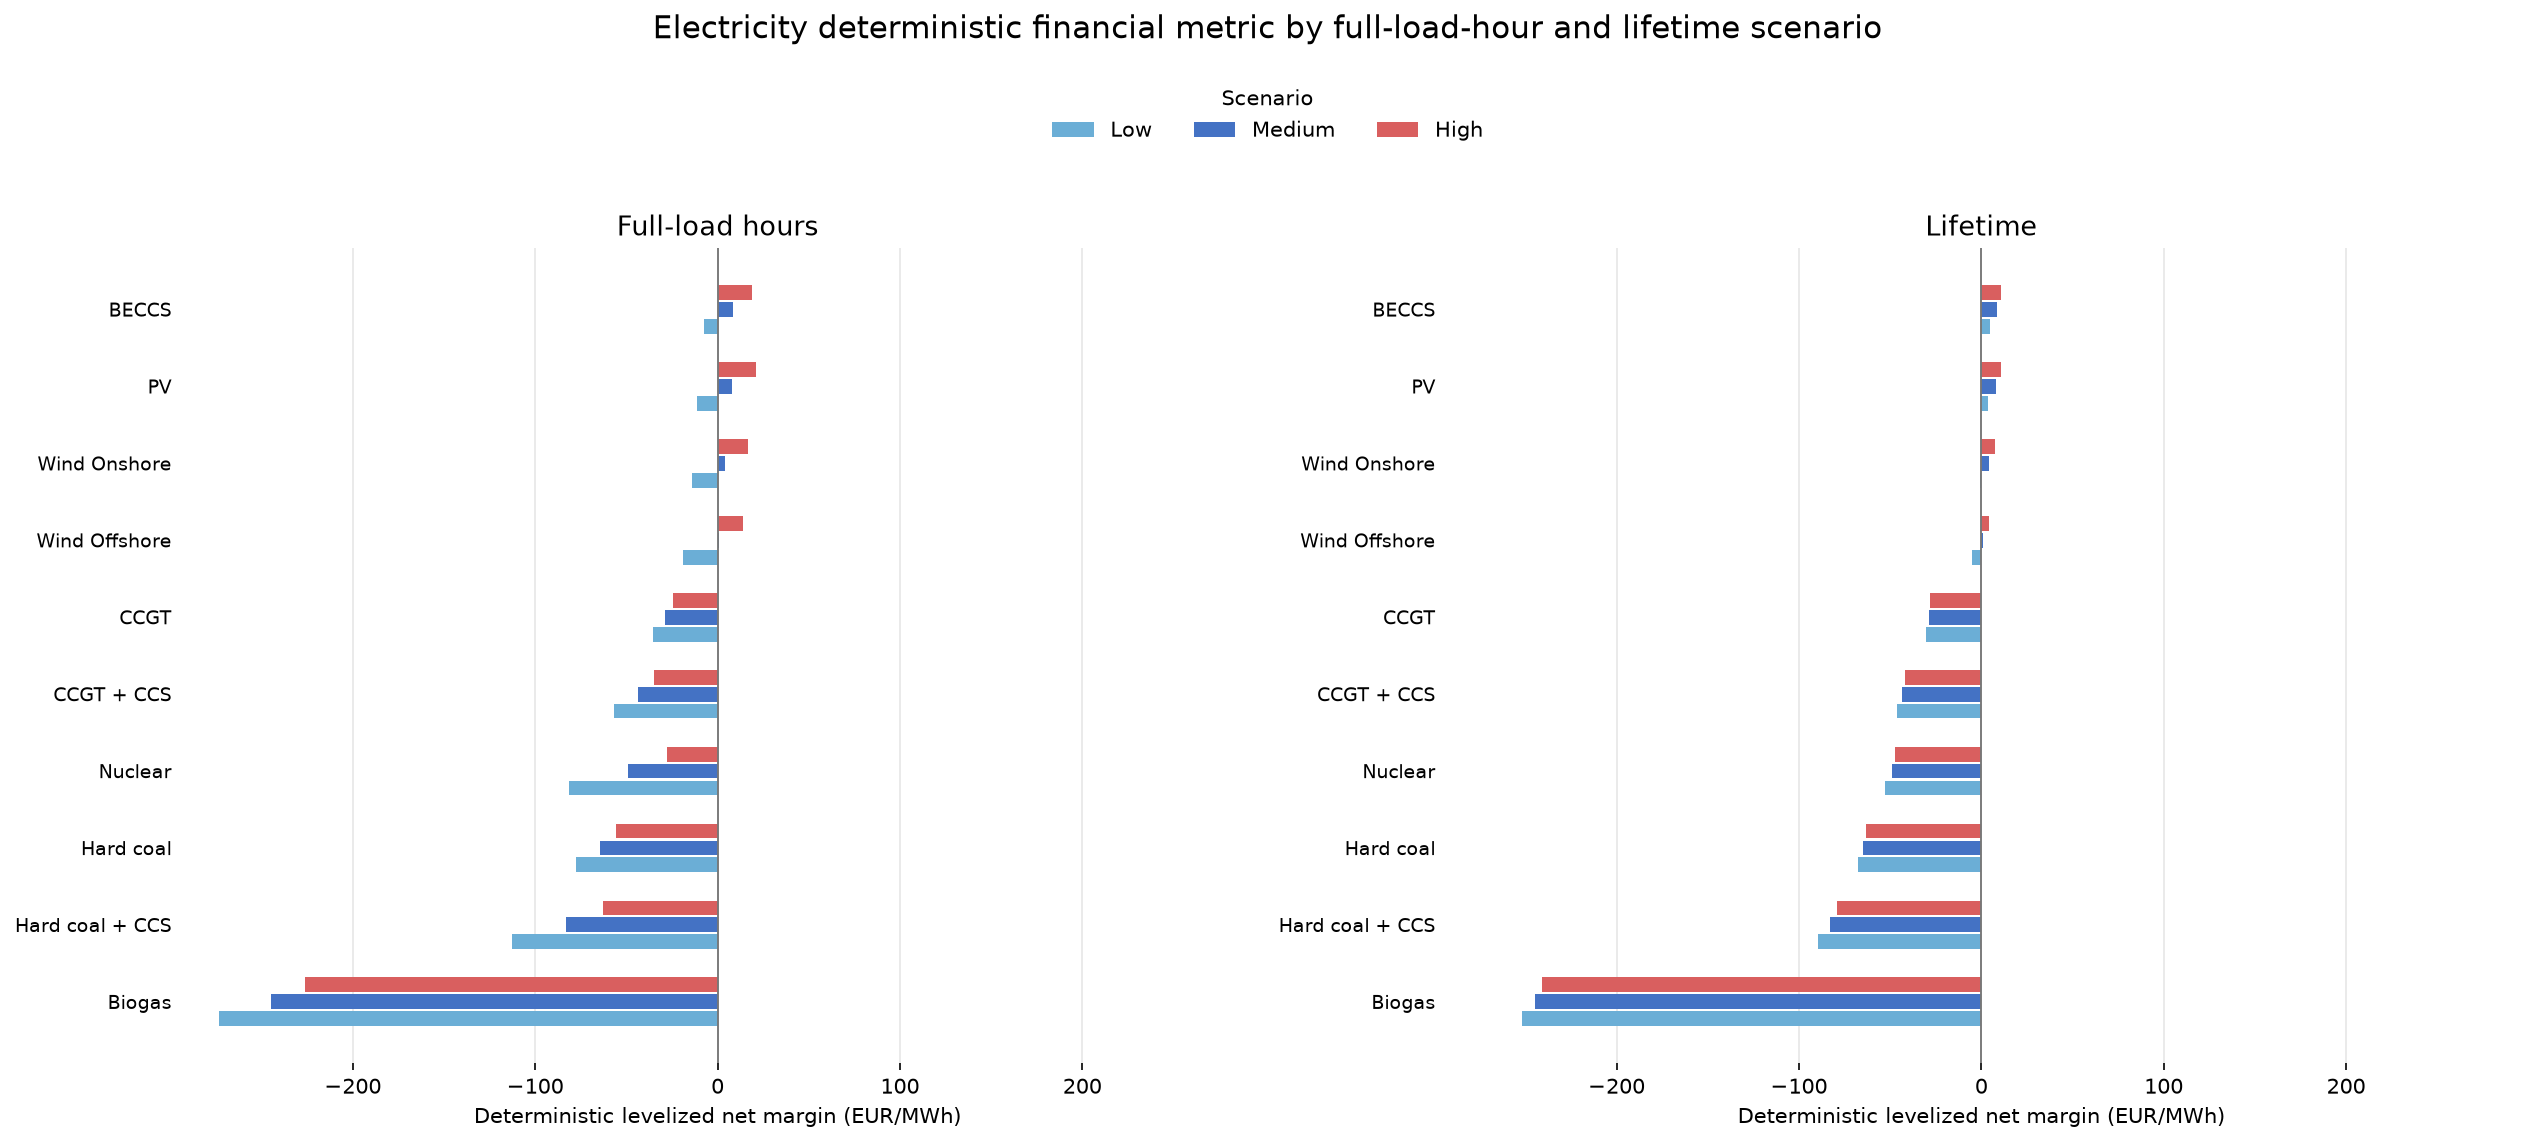

In [5]:
electricity_summary = pd.concat(
    [
        build_deterministic_scenario_summary(
            "electricity",
            electricity_base_inputs,
            ELECTRICITY_TECHNOLOGY_LABELS,
            "Full-load hours",
            "full_load_hours",
            ELECTRICITY_FLH_MULTIPLIERS,
            values_are_multipliers=True,
        ),
        build_deterministic_scenario_summary(
            "electricity",
            electricity_base_inputs,
            ELECTRICITY_TECHNOLOGY_LABELS,
            "Lifetime",
            "lifetime_years",
            ELECTRICITY_LIFETIME_MULTIPLIERS,
            values_are_multipliers=True,
        ),
    ],
    ignore_index=True,
)

display(electricity_summary)
plot_scenario_variables(
    electricity_summary,
    "Electricity deterministic financial metric by full-load-hour and lifetime scenario",
    "electricity",
)
plt.show()


## Renewable electricity value-factor scenarios

The value factor scales the existing electricity sales-price proxy for onshore wind, offshore wind, and solar PV. The minimum, base (distribution mode), and maximum values match the triangular Monte Carlo assumptions. The main deterministic model uses the analytical triangular mean; this scenario panel deliberately compares the supplied minimum, mode, and maximum. Value factors affect revenue, NPV, and LNM; they do not affect the cost-only LCOE (`LCOX`).


,sector,technology,label,scenario_variable,scenario,scenario_setting,base_value,applied_value,metric_value,delta_from_base
0,Electricity,wind_onshore,Wind Onshore,Value factor,Min,0.800,0.900,0.800,-5.158,-9.407
1,Electricity,wind_onshore,Wind Onshore,Value factor,Base,0.900,0.900,0.900,4.249,0.000
2,Electricity,wind_onshore,Wind Onshore,Value factor,Max,1.000,0.900,1.000,13.656,9.407
3,Electricity,wind_offshore,Wind Offshore,Value factor,Min,0.850,0.933,0.850,-6.905,-7.839
4,Electricity,wind_offshore,Wind Offshore,Value factor,Base,0.950,0.933,0.950,2.502,1.568
5,Electricity,wind_offshore,Wind Offshore,Value factor,Max,1.000,0.933,1.000,7.206,6.271
6,Electricity,pv,PV,Value factor,Min,0.800,0.900,0.800,-1.309,-9.407
7,Electricity,pv,PV,Value factor,Base,0.900,0.900,0.900,8.098,0.000
8,Electricity,pv,PV,Value factor,Max,1.000,0.900,1.000,17.505,9.407


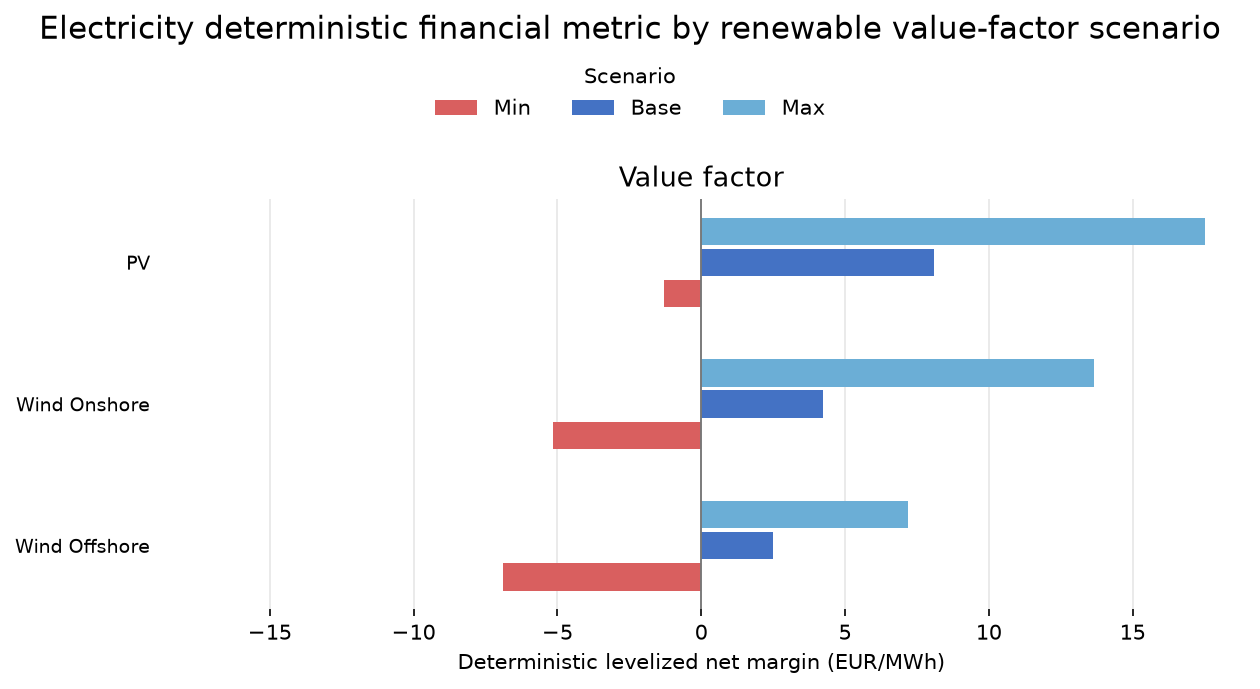

In [6]:
electricity_value_factor_summary = pd.concat(
    [
        build_deterministic_scenario_summary(
            "electricity",
            {technology: electricity_base_inputs[technology]},
            ELECTRICITY_TECHNOLOGY_LABELS,
            "Value factor",
            "value_factor",
            scenarios,
        )
        for technology, scenarios in ELECTRICITY_VALUE_FACTOR_SCENARIOS.items()
    ],
    ignore_index=True,
)

value_factor_metrics = electricity_value_factor_summary.pivot(
    index="technology",
    columns="scenario",
    values="metric_value",
)
if FINANCIAL_METRIC in {"NPV", "LNM"}:
    assert (value_factor_metrics["Max"] > value_factor_metrics["Base"]).all()
    assert (value_factor_metrics["Base"] > value_factor_metrics["Min"]).all()
else:
    np.testing.assert_allclose(
        value_factor_metrics.loc[:, VF_SCENARIO_ORDER],
        np.repeat(
            value_factor_metrics[["Base"]].to_numpy(),
            len(VF_SCENARIO_ORDER),
            axis=1,
        ),
    )

display(electricity_value_factor_summary)
plot_scenario_variables(
    electricity_value_factor_summary,
    "Electricity deterministic financial metric by renewable value-factor scenario",
    "electricity",
    scenario_order=VF_SCENARIO_ORDER,
    scenario_colors=VF_SCENARIO_COLORS,
    reference_scenario="Base",
    figure_height=4.5,
)
plt.show()


## Cement scenarios: CO2 price and discount rate

CO2 price and discount rate use explicit low / medium / high values. All other cement inputs remain fixed at their deterministic base values.


,sector,technology,label,scenario_variable,scenario,scenario_setting,base_value,applied_value,metric_value,delta_from_base
0,Cement,bau,BAU,CO2 price,Low,40.000,80.000,40.000,71.999,25.333
1,Cement,bau,BAU,CO2 price,Medium,80.000,80.000,80.000,46.666,0.000
2,Cement,bau,BAU,CO2 price,High,120.000,80.000,120.000,21.333,-25.333
3,Cement,electrification,Electrification,CO2 price,Low,40.000,80.000,40.000,-24.680,16.000
4,Cement,electrification,Electrification,CO2 price,Medium,80.000,80.000,80.000,-40.680,0.000
5,Cement,electrification,Electrification,CO2 price,High,120.000,80.000,120.000,-56.680,-16.000
6,Cement,electrolysis,Electrolysis,CO2 price,Low,40.000,80.000,40.000,-220.628,4.000
7,Cement,electrolysis,Electrolysis,CO2 price,Medium,80.000,80.000,80.000,-224.628,0.000
8,Cement,electrolysis,Electrolysis,CO2 price,High,120.000,80.000,120.000,-228.628,-4.000
9,Cement,clinker_substitution,Clinker substitution,CO2 price,Low,40.000,80.000,40.000,72.001,22.167


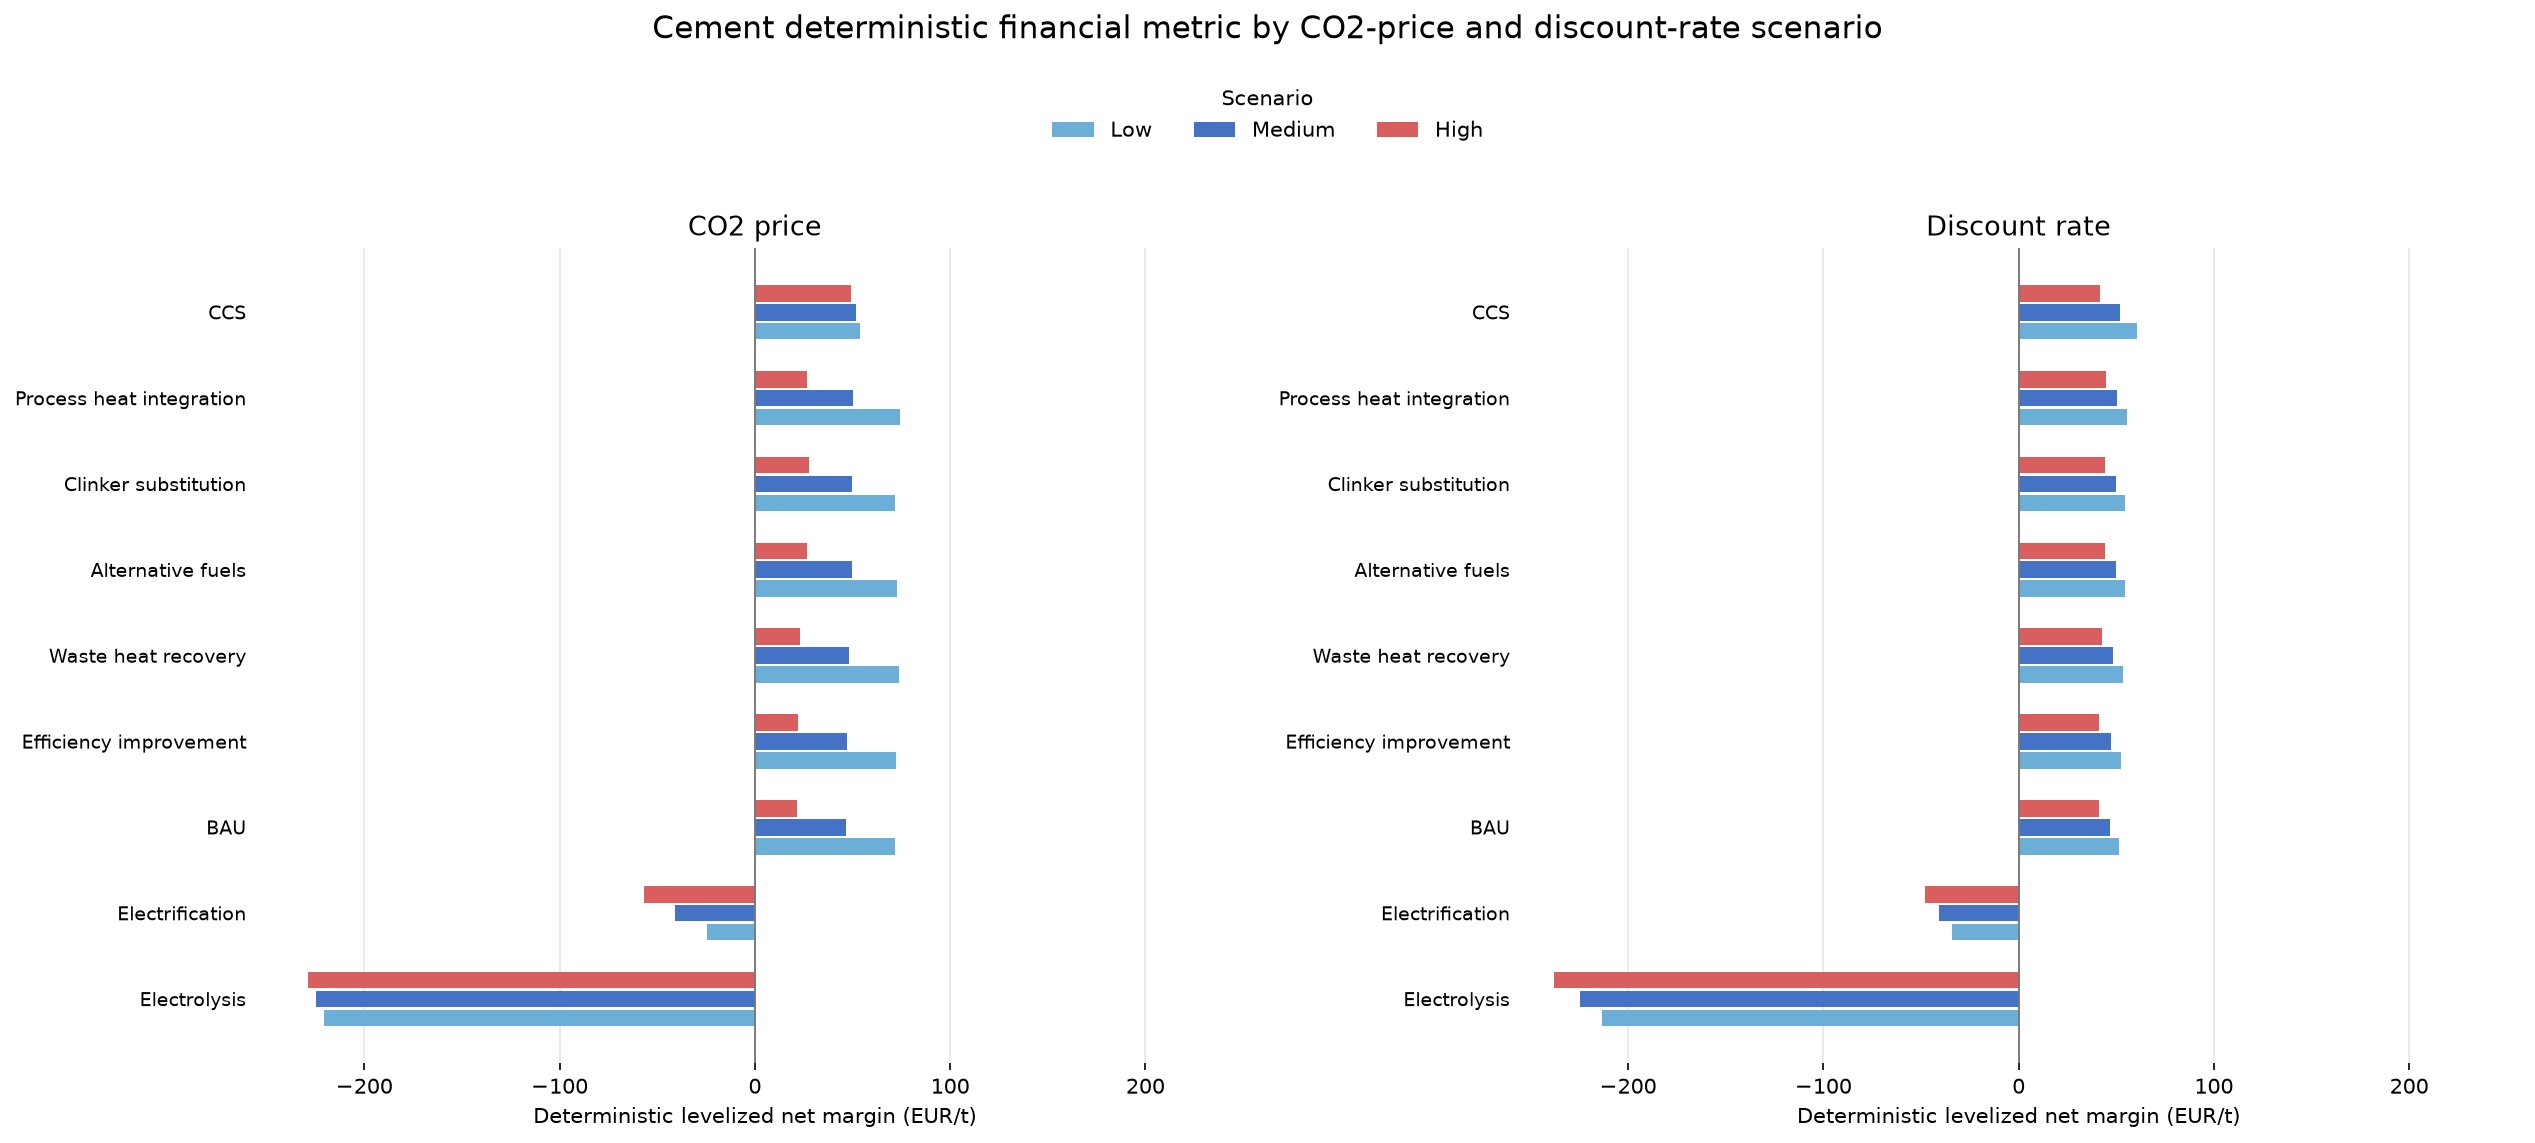

In [7]:
cement_summary = pd.concat(
    [
        build_deterministic_scenario_summary(
            "cement",
            cement_base_inputs,
            CEMENT_TECHNOLOGY_LABELS,
            "CO2 price",
            "carbon_price",
            CEMENT_CO2_PRICE_SCENARIOS,
        ),
        build_deterministic_scenario_summary(
            "cement",
            cement_base_inputs,
            CEMENT_TECHNOLOGY_LABELS,
            "Discount rate",
            "discount_rate",
            CEMENT_DISCOUNT_RATE_SCENARIOS,
        ),
    ],
    ignore_index=True,
)

display(cement_summary)
plot_scenario_variables(
    cement_summary,
    "Cement deterministic financial metric by CO2-price and discount-rate scenario",
    "cement",
)
plt.show()


## Hydrogen scenarios: fuel price, electricity price, and investment cost

The low, medium, and high cases apply 80%, 100%, and 120% multipliers to one input at a time. Fuel prices remain technology-specific: natural gas, biomethane, and biomass routes each scale their own deterministic price, while electrolysis routes have no fuel-price response. The electricity-price scenario scales the common deterministic electricity price, and the investment-cost scenario scales each technology's CAPEX. All technical consumption values and other inputs remain fixed.


,sector,technology,label,scenario_variable,scenario,scenario_setting,base_value,applied_value,metric_value,delta_from_base
0,Hydrogen,ng_smr,NG-SMR,Fuel price,Low,0.800,39.300,31.440,"5,074.823",344.975
1,Hydrogen,ng_smr,NG-SMR,Fuel price,Medium,1.000,39.300,39.300,"4,729.848",0.000
2,Hydrogen,ng_smr,NG-SMR,Fuel price,High,1.200,39.300,47.160,"4,384.872",-344.975
3,Hydrogen,ael,AEL,Fuel price,Low,0.800,0.000,0.000,408.283,0.000
4,Hydrogen,ael,AEL,Fuel price,Medium,1.000,0.000,0.000,408.283,0.000
...,...,...,...,...,...,...,...,...,...,...
67,Hydrogen,biomethane_smr,Biomethane SMR,Investment cost,Medium,1.000,"2,308.333","2,308.333","3,334.350",0.000
68,Hydrogen,biomethane_smr,Biomethane SMR,Investment cost,High,1.200,"2,308.333","2,770.000","3,291.101",-43.248
69,Hydrogen,ng_smr_ccs,NG-SMR + CCS,Investment cost,Low,0.800,"4,047.000","3,237.600","4,867.851",90.003
70,Hydrogen,ng_smr_ccs,NG-SMR + CCS,Investment cost,Medium,1.000,"4,047.000","4,047.000","4,777.849",0.000


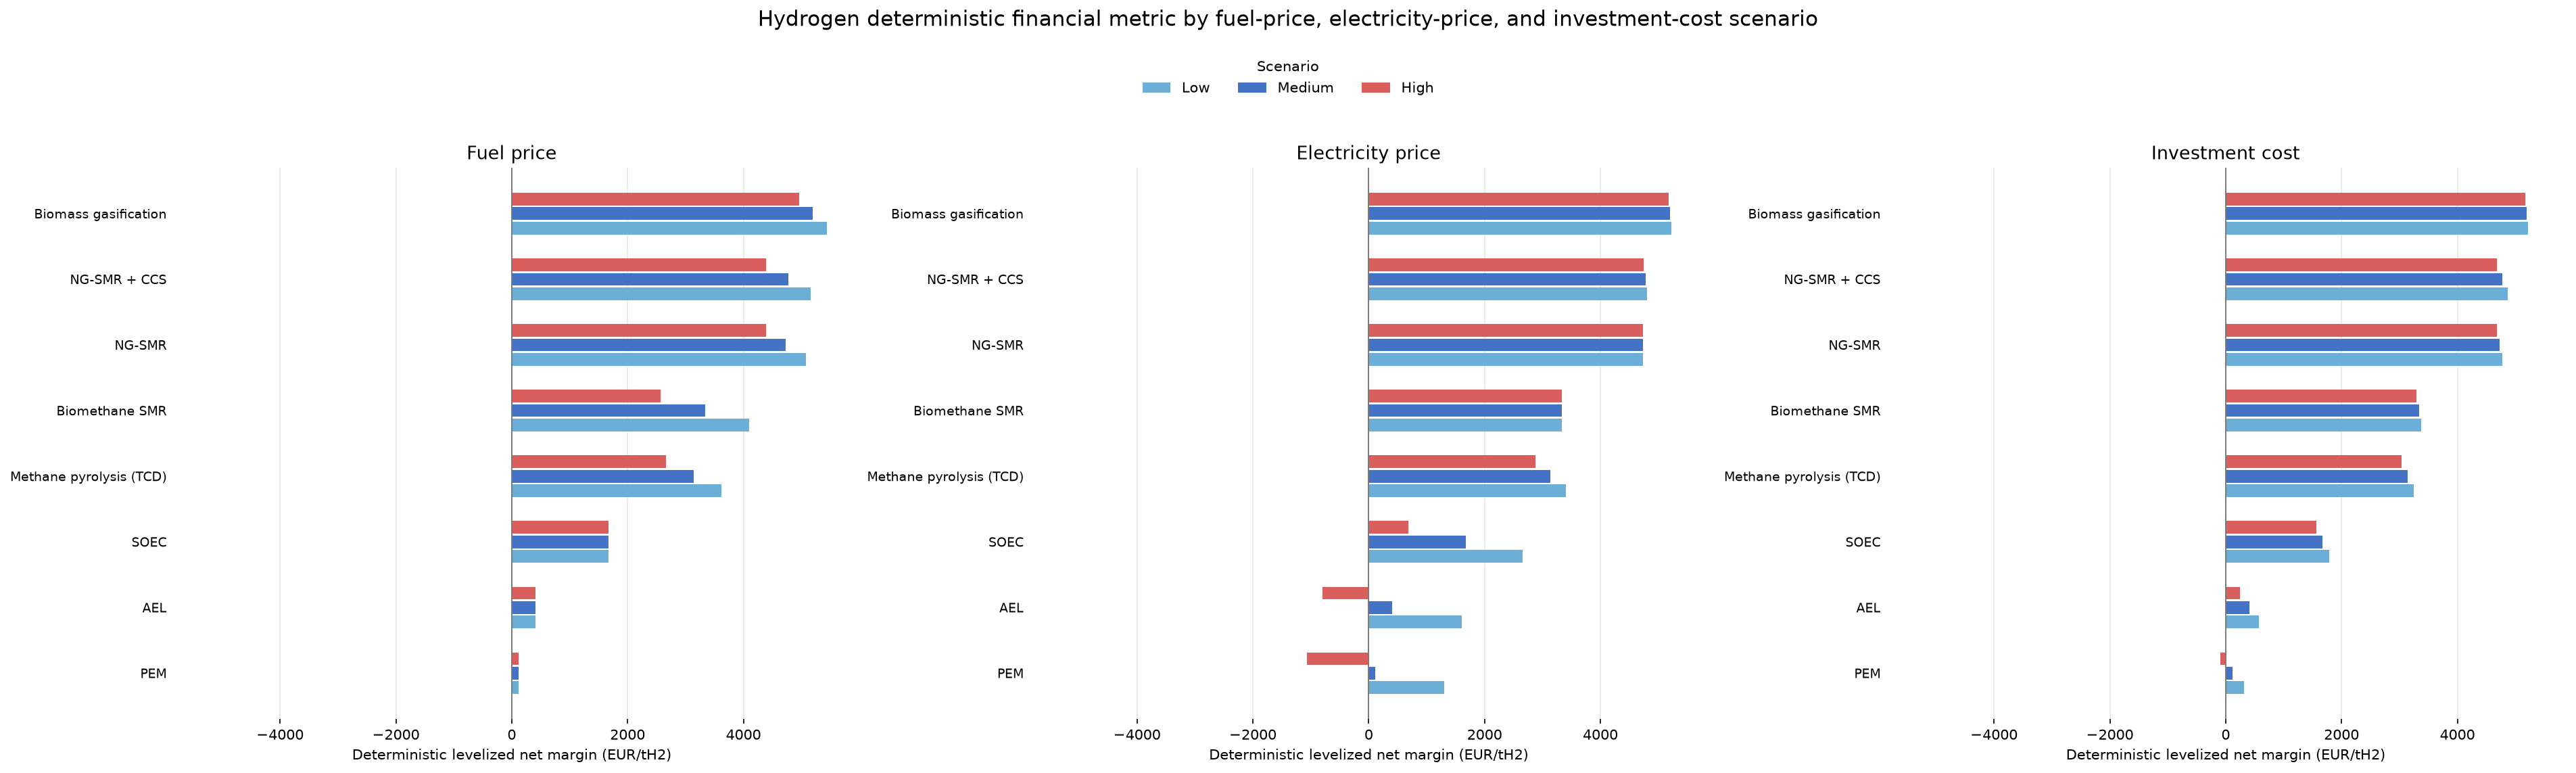

In [8]:
hydrogen_summary = pd.concat(
    [
        build_deterministic_scenario_summary(
            "hydrogen",
            hydrogen_base_inputs,
            HYDROGEN_TECHNOLOGY_LABELS,
            scenario_variable,
            attribute,
            HYDROGEN_INPUT_MULTIPLIERS,
            values_are_multipliers=True,
        )
        for scenario_variable, attribute in (
            ("Fuel price", "fuel_price"),
            ("Electricity price", "electricity_price"),
            ("Investment cost", "capex"),
        )
    ],
    ignore_index=True,
)

display(hydrogen_summary)
plot_scenario_variables(
    hydrogen_summary,
    "Hydrogen deterministic financial metric by fuel-price, electricity-price, and investment-cost scenario",
    "hydrogen",
    figure_height=7.5,
)
plt.show()


## Ammonia scenarios: electricity price, investment cost, and fuel price

These are the three highest-impact input groups across the ammonia sensitivity heatmap. The low, medium, and high cases apply 80%, 100%, and 120% multipliers to one input at a time. Fuel prices remain route-specific: natural gas, coal, and biomass routes scale their applicable deterministic fuel price; routes without fuel consumption remain unchanged. The electricity-price scenario scales the shared deterministic electricity price, and the investment-cost scenario scales each route's CAPEX. Consumption intensities and all other inputs remain fixed. For CCS routes, the shared transport-and-storage surcharge is recalculated when the affected capture-cost inputs change.

,sector,technology,label,scenario_variable,scenario,scenario_setting,base_value,applied_value,metric_value,delta_from_base
0,Ammonia,ng_smr_hb,NG-SMR + HB,Electricity price,Low,0.800,116.600,93.280,268.377,0.000
1,Ammonia,ng_smr_hb,NG-SMR + HB,Electricity price,Medium,1.000,116.600,116.600,268.377,0.000
2,Ammonia,ng_smr_hb,NG-SMR + HB,Electricity price,High,1.200,116.600,139.920,268.377,0.000
3,Ammonia,coal_gasification_hb,Coal gasification + HB,Electricity price,Low,0.800,116.600,93.280,-4.595,24.020
4,Ammonia,coal_gasification_hb,Coal gasification + HB,Electricity price,Medium,1.000,116.600,116.600,-28.615,0.000
...,...,...,...,...,...,...,...,...,...,...
76,Ammonia,ng_smr_hb_ccs,NG-SMR + HB + CCS,Fuel price,Medium,1.000,39.300,39.300,330.513,0.000
77,Ammonia,ng_smr_hb_ccs,NG-SMR + HB + CCS,Fuel price,High,1.200,39.300,47.160,263.834,-66.679
78,Ammonia,coal_gasification_hb_ccs,Coal gasification + HB + CCS,Fuel price,Low,0.800,12.110,9.688,114.101,22.670
79,Ammonia,coal_gasification_hb_ccs,Coal gasification + HB + CCS,Fuel price,Medium,1.000,12.110,12.110,91.431,0.000


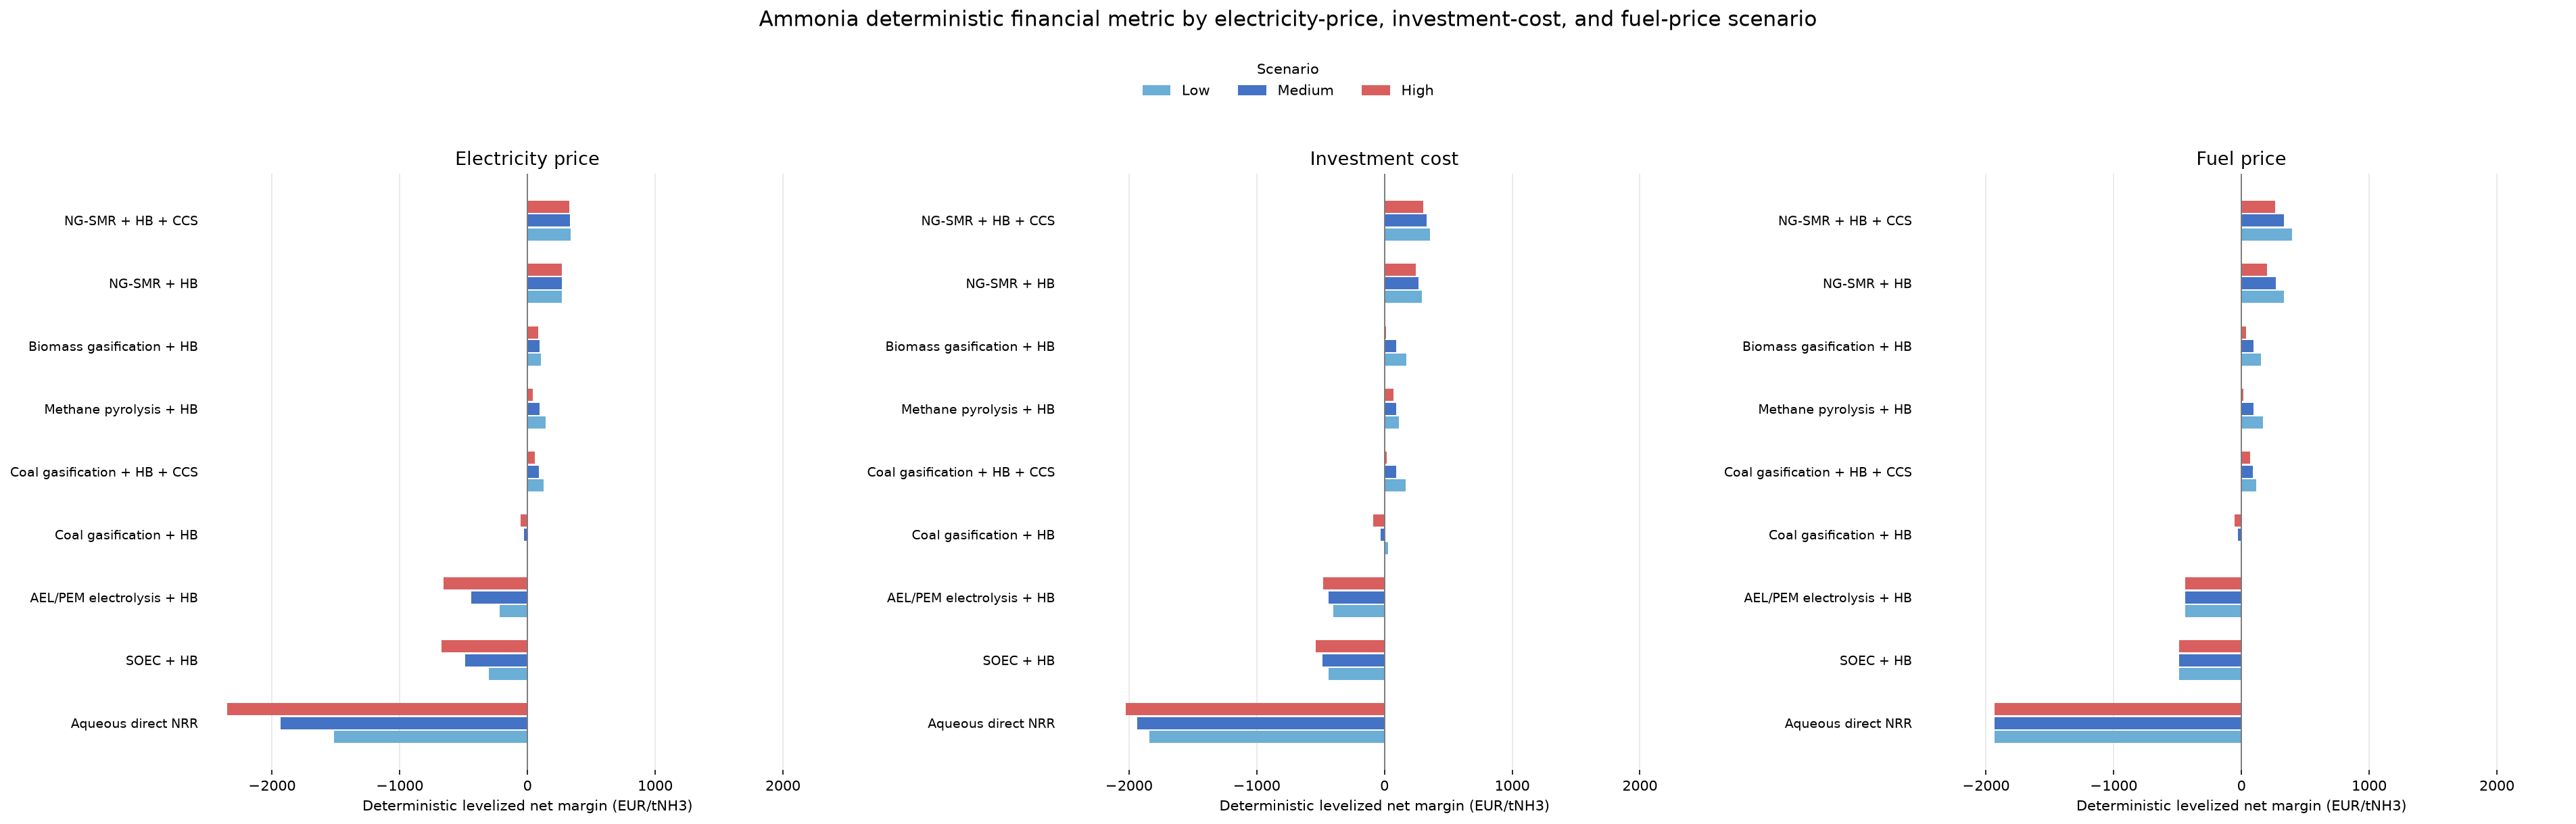

In [9]:
ammonia_summary = pd.concat(
    [
        build_deterministic_scenario_summary(
            "ammonia",
            ammonia_base_inputs,
            AMMONIA_TECHNOLOGY_LABELS,
            scenario_variable,
            attribute,
            AMMONIA_INPUT_MULTIPLIERS,
            values_are_multipliers=True,
        )
        for scenario_variable, attribute in (
            ("Electricity price", "electricity_price"),
            ("Investment cost", "capex"),
            ("Fuel price", "fuel_price"),
        )
    ],
    ignore_index=True,
)

# Energy-free routes remain fixed in the fuel-price scenario; NG-SMR + HB has
# zero purchased electricity and therefore remains fixed in that price scenario.
fuel_price_pivot = ammonia_summary.loc[
    ammonia_summary["scenario_variable"] == "Fuel price"
].pivot(index="technology", columns="scenario", values="metric_value")
for technology in ("ael_pem_electrolysis_hb", "soec_hb", "aqueous_direct_nrr"):
    np.testing.assert_allclose(
        fuel_price_pivot.loc[technology, SCENARIO_ORDER],
        fuel_price_pivot.loc[technology, "Medium"],
    )

electricity_price_pivot = ammonia_summary.loc[
    ammonia_summary["scenario_variable"] == "Electricity price"
].pivot(index="technology", columns="scenario", values="metric_value")
np.testing.assert_allclose(
    electricity_price_pivot.loc["ng_smr_hb", SCENARIO_ORDER],
    electricity_price_pivot.loc["ng_smr_hb", "Medium"],
)

display(ammonia_summary)
plot_scenario_variables(
    ammonia_summary,
    "Ammonia deterministic financial metric by electricity-price, investment-cost, and fuel-price scenario",
    "ammonia",
    figure_height=8.0,
)
plt.show()

## Interpretation guardrails

- The renewable minimum/base/maximum scenarios match the triangular value-factor parameters in `src/`.
- The medium cases come from the deterministic base assumptions in `src/`.
- The renewable Base values are the deterministic triangular means: 0.90 for onshore wind and PV, and 0.933 for offshore wind.
- Monte Carlo electricity simulations sample the full value-factor ranges.
- Value factors scale captured electricity price and sales revenue only; generation, capacity, costs, and LCOE remain unchanged.
- Scenario comparisons are deterministic: no Monte Carlo simulations or sampled scenario cases are used.
- Electricity FLH and lifetime scenarios use relative multipliers because the deterministic base values differ by technology.
- Cement CO2-price and discount-rate scenarios use absolute editable values.
- Hydrogen fuel price, electricity price, and CAPEX are varied one at a time by ±20%; the scenario does not vary fuel or electricity consumption.
- Hydrogen routes without the relevant energy input remain unchanged in that price scenario.
- Biomethane SMR uses the provisional fixed biomethane base price of 87.5 EUR/MWh_th before the scenario multiplier is applied.

- Ammonia electricity price, fuel price, and CAPEX are varied one at a time by ±20%; consumption intensities stay fixed.
- Ammonia routes without the relevant energy input remain unchanged in that price scenario; biomass gasification scales the shared BECCS biomass-price proxy.